## Cell 1 — Imports & setup

In [18]:
# Cell 1 — imports
import os
import pandas as pd
import numpy as np

from surprise import SVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import linear_kernel

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8,5), "figure.dpi": 120})


## Cell 2 — Load processed data

In [19]:
# Cell 2 — load data
ratings = pd.read_csv("data/processed/ratings_clean.csv")
movies = pd.read_csv("data/processed/movies_meta.csv")
movies_content = pd.read_csv("data/processed/movies_content.csv")

ratings.head(), movies.head()


(   userId  movieId  rating  timestamp
 0     196      242     3.0  881250949
 1     186      302     3.0  891717742
 2      22      377     1.0  878887116
 3     244       51     2.0  880606923
 4     166      346     1.0  886397596,
    movieId              title  genre_0  genre_1  genre_2  genre_3  genre_4  \
 0        1   Toy Story (1995)        0        0        0        1        1   
 1        2   GoldenEye (1995)        0        1        1        0        0   
 2        3  Four Rooms (1995)        0        0        0        0        0   
 3        4  Get Shorty (1995)        0        1        0        0        0   
 4        5     Copycat (1995)        0        0        0        0        0   
 
    genre_5  genre_6  genre_7  ...  genre_9  genre_10  genre_11  genre_12  \
 0        1        0        0  ...        0         0         0         0   
 1        0        0        0  ...        0         0         0         0   
 2        0        0        0  ...        0         0     

## Cell 3 — Load trained CF model (or retrain)

In [20]:
# Cell 3 — train collaborative filtering model
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']],
    reader
)

trainset = data.build_full_trainset()

cf_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

cf_model.fit(trainset)
print("Collaborative Filtering model ready.")


Collaborative Filtering model ready.


## Cell 4 — Load content similarity matrix

In [21]:
# Cell 4 — load content similarity matrix
cosine_sim = np.load("data/processed/content_cosine_sim.npy")

# mapping
title_to_index = pd.Series(
    movies_content.index,
    index=movies_content['title']
).drop_duplicates()

# movieId → index mapping for content matrix
movieid_to_index = pd.Series(
    movies_content.index,
    index=movies_content['movieId']
).to_dict()


## STEP 1 — Get Collaborative Filtering scores

In [22]:
# Cell 5 — CF prediction helper
def get_cf_scores(user_id, candidate_movie_ids):
    """
    Predict CF ratings for a list of movies
    """
    return {
        movie_id: cf_model.predict(user_id, movie_id).est
        for movie_id in candidate_movie_ids
    }


## STEP 2 — Get Content Similarity scores

In [23]:
# Cell 6 — content similarity helper
def get_content_scores(user_id, liked_threshold=4.0):
    """
    Compute content similarity scores based on movies the user liked
    """
    liked_movies = ratings[
        (ratings['userId'] == user_id) &
        (ratings['rating'] >= liked_threshold)
    ]['movieId'].unique()

    # keep only movies present in content matrix
    liked_indices = [
        movieid_to_index[mid]
        for mid in liked_movies
        if mid in movieid_to_index
    ]

    # cold-start fallback
    if len(liked_indices) == 0:
        return {}

    # average similarity vector
    sim_scores = cosine_sim[liked_indices].mean(axis=0)

    # return as movieId → score
    return {
        movies_content.iloc[i]['movieId']: sim_scores[i]
        for i in range(len(sim_scores))
    }


## STEP 3 — Normalize scores

In [24]:
# Cell 7 — normalization helper
def normalize_scores(score_dict):
    if not score_dict:
        return {}

    scaler = MinMaxScaler()
    keys = list(score_dict.keys())
    values = np.array(list(score_dict.values())).reshape(-1,1)

    scaled = scaler.fit_transform(values).flatten()
    return dict(zip(keys, scaled))


## STEP 4 — Hybrid Recommendation Function

In [25]:
# Cell 8 — Hybrid Recommender
def recommend_hybrid(user_id, n=10, w_cf=0.6, w_content=0.4):
    """
    Hybrid recommender: CF + Content
    """
    # Movies already seen
    seen_movies = ratings[ratings['userId'] == user_id]['movieId'].unique()

    # Candidate movies
    candidates = movies[~movies['movieId'].isin(seen_movies)]

    # CF scores
    cf_scores = get_cf_scores(user_id, candidates['movieId'])
    cf_scores = normalize_scores(cf_scores)

    # Content scores
    content_scores = get_content_scores(user_id)
    content_scores = normalize_scores(content_scores)

    # Combine
    final_scores = {}
    for movie_id in candidates['movieId']:
        cf = cf_scores.get(movie_id, 0)
        content = content_scores.get(movie_id, 0)
        final_scores[movie_id] = w_cf * cf + w_content * content

    # Rank
    ranked = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:n]

    result = pd.DataFrame(ranked, columns=['movieId','hybrid_score'])
    result = result.merge(movies[['movieId','title']], on='movieId')

    return result

recommend_hybrid(user_id=1, n=10)


,movieId,hybrid_score,title
0,531,0.883086,Shine (1996)
1,919,0.832219,"City of Lost Children, The (1995)"
2,475,0.824207,Trainspotting (1996)
3,276,0.818714,Leaving Las Vegas (1995)
4,313,0.816086,Titanic (1997)
5,318,0.796665,Schindler's List (1993)
6,936,0.790357,Brassed Off (1996)
7,474,0.788131,Dr. Strangelove or: How I Learned to Stop Worr...
8,483,0.776745,Casablanca (1942)
9,1628,0.776659,Lamerica (1994)


## Optional — Visualize Hybrid Scores

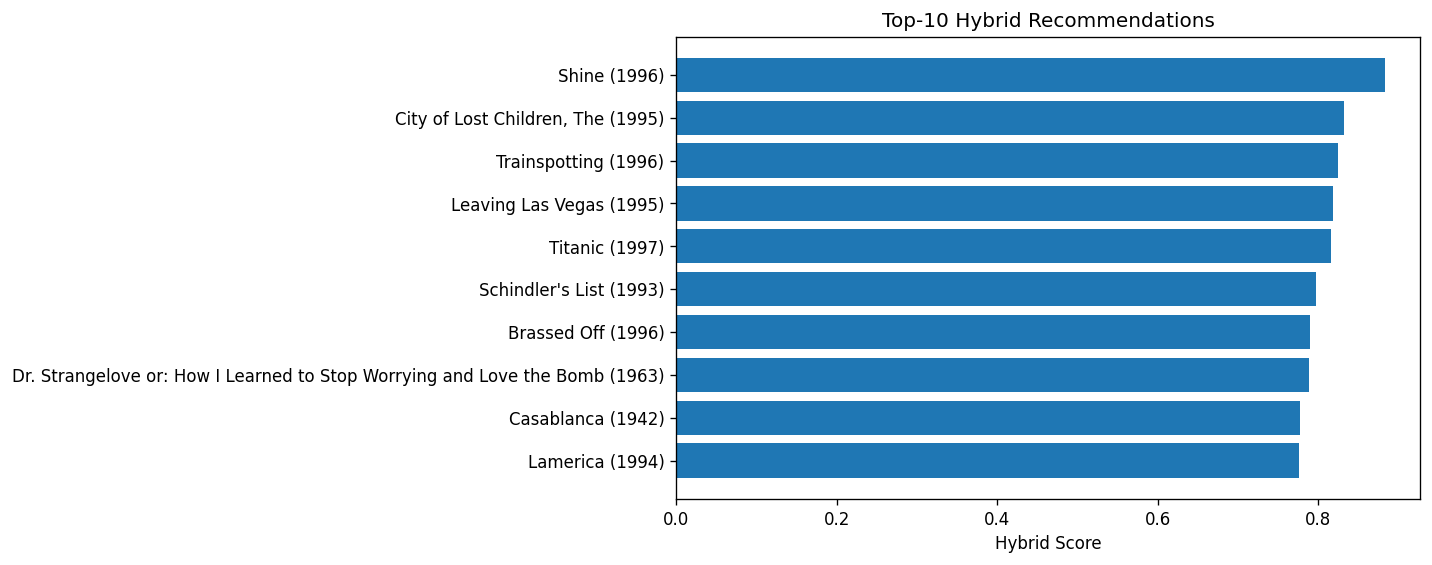

In [26]:
# Cell 10 — visualization
recs = recommend_hybrid(1, 10)

plt.barh(recs['title'][::-1], recs['hybrid_score'][::-1])
plt.xlabel("Hybrid Score")
plt.title("Top-10 Hybrid Recommendations")
plt.show()


## Optional — Save Hybrid Results

In [27]:
# Cell 11 — save output
recs.to_csv("data/processed/sample_hybrid_recommendations.csv", index=False)
